In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import myplotlib
import myplotlib.plots as myplt
import compton
myplotlib.load()

In [16]:
gamma = 10
gamma_beta = np.sqrt(gamma**2 - 1.0)
p_particle = np.array([gamma, gamma_beta, 0.0, 0.0])

e_photon = 0.001
p_photons = np.array(
    [e_photon * np.array([1.0, *compton.generateRandomDirection()]) for i in range(10000)])

In [17]:
e_photons = compton.ComptonScatter(p_particle, p_photons)

1.8276766544624727


In [18]:
energies = None;
with h5py.File("../build/prtls.h5", "r") as f:
    energies = f["e_ph"][:]

/Users/hayk/Codes/ragnar/compton.py:11: RuntimeWarning: divide by zero encountered in log
  return 2 * q * np.log(q) + (1 + 2 * q) * (1 - q) + 0.5 * Gamma**2 * q**2 * (1 - q) / (1 + Gamma * q)
/Users/hayk/Codes/ragnar/compton.py:11: RuntimeWarning: invalid value encountered in multiply
  return 2 * q * np.log(q) + (1 + 2 * q) * (1 - q) + 0.5 * Gamma**2 * q**2 * (1 - q) / (1 + Gamma * q)


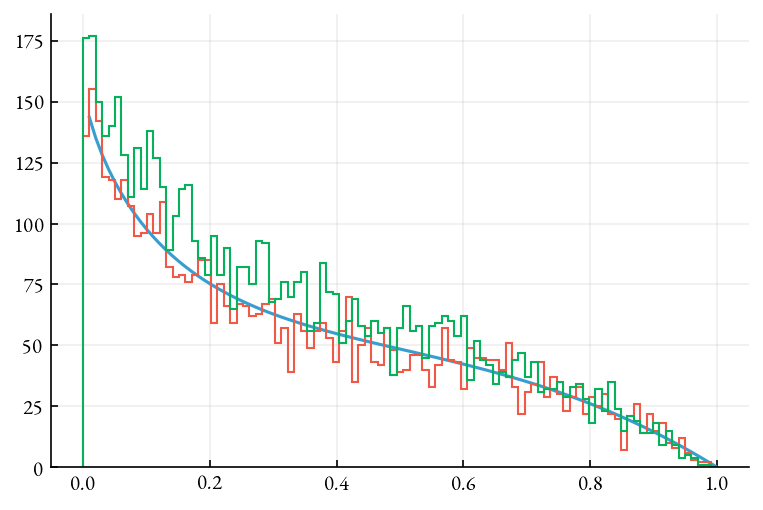

In [19]:
Gamma = 4 * gamma * e_photon
emax = Gamma * gamma / (1.0 + Gamma)

# plt.hist(energies, bins=np.linspace(0, 10, 40), histtype='step');
xs = np.linspace(0, 1, 100)
ys = compton.Jonesth(Gamma, xs)
ys /= np.nansum(ys)
ys *= len(e_photons)
plt.plot(xs, ys)
plt.hist(e_photons / emax, bins=np.linspace(
    0, 1, 100), histtype='step');
plt.hist(energies[energies != e_photon] / emax, bins=np.linspace(
    0, 1, 100), histtype='step');


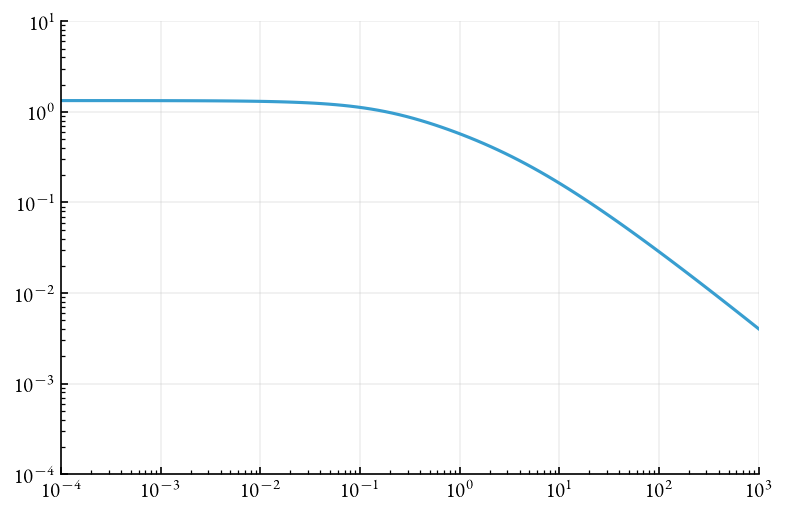

In [7]:
# (1.0 + e_ph) / CUBE(e_ph)
#                    * (2.0 * e_ph * (1.0 + e_ph) / (1.0 + 2.0 * e_ph)
#                       - std: : log(1.0 + 2.0 * e_ph))
#                  + std::log(1.0 + 2.0 * e_ph) / (2.0 * e_ph)
#                  - (1.0 + 3.0 * e_ph) / SQR(1.0 + 2.0 * e_ph);
def sigma(eph):
    return (1 + eph) / eph**3 * (2 * eph * (1 + eph) / (1 + 2 * eph) - np.log(1 + 2 * eph)) + np.log(1 + 2 * eph) / (2 * eph) - (1 + 3 * eph) / (1 + 2 * eph)**2
    
xs = np.logspace(-4, 3, 100)
ys = sigma(xs)

fig, ax = plt.subplots()
myplt.plot(ax, xs, ys, xlog=True, ylog=True, xlim=(1e-4, 1e3), ylim=(1e-4, 10))